In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

df = pd.concat([X, y], axis=1)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


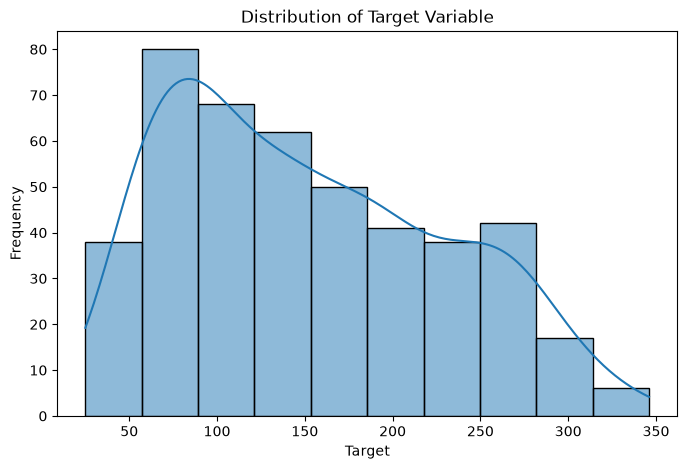

In [3]:
plt.figure(figsize=(8, 5))

sns.histplot(df["target"], kde=True)

plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Frequency")

plt.show()

In [4]:
skewness = df["target"].skew()

print("Skewness:", skewness)

Skewness: 0.44056293407014124


In [5]:
correlation_matrix = df.corr()

print(correlation_matrix)

             age       sex       bmi        bp        s1        s2        s3  \
age     1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
sex     0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
bmi     0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
bp      0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
s1      0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
s2      0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
s3     -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
s4      0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
s5      0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
s6      0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   
target  0.187889  0.043062  0.586450  0.441482  0.212022  0.174054 -0.394789   

              s4        s5        s6   

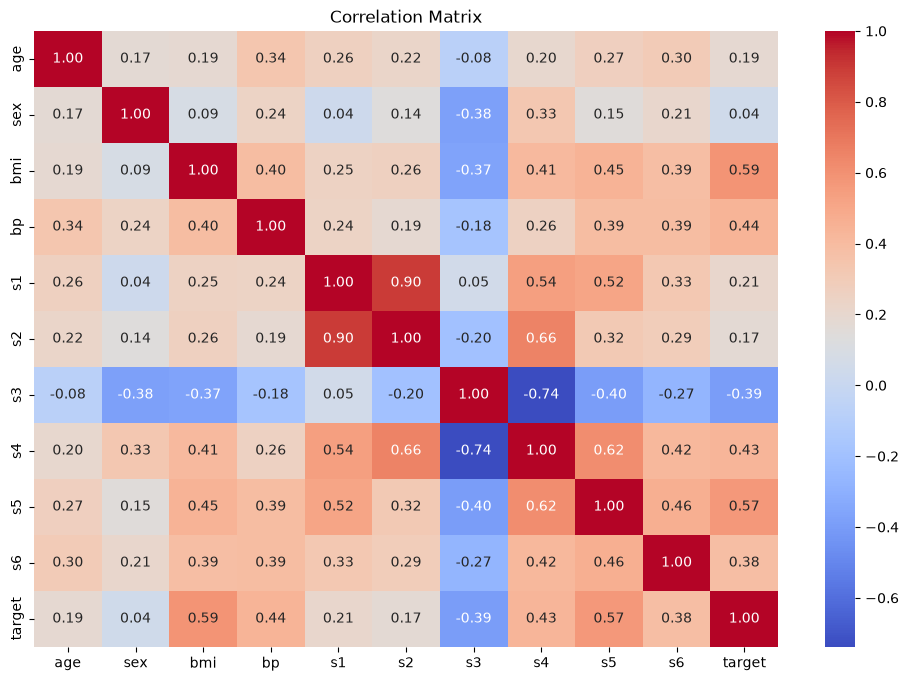

In [6]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [7]:
target_corr = correlation_matrix["target"].sort_values(
    ascending=False
)

print(target_corr)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [8]:
print(
    target_corr.drop("target").sort_values(
        key=abs,
        ascending=False
    )
)

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64


In [9]:
X_simple = df[["bmi"]]
y = df["target"]

In [10]:
df[["bmi"]]

,bmi
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385
...,...
437,0.019662
438,-0.015906
439,-0.015906
440,0.039062


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[998.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['bmi']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [13]:
beta_0 = simple_model.intercept_

print("Intercept (β0):", beta_0)

Intercept (β0): 152.00335421448167


In [14]:
beta_1 = simple_model.coef_[0]

print("Slope (β1):", beta_1)

Slope (β1): 998.5776891375593


In [15]:
y_pred_simple = simple_model.predict(X_test)

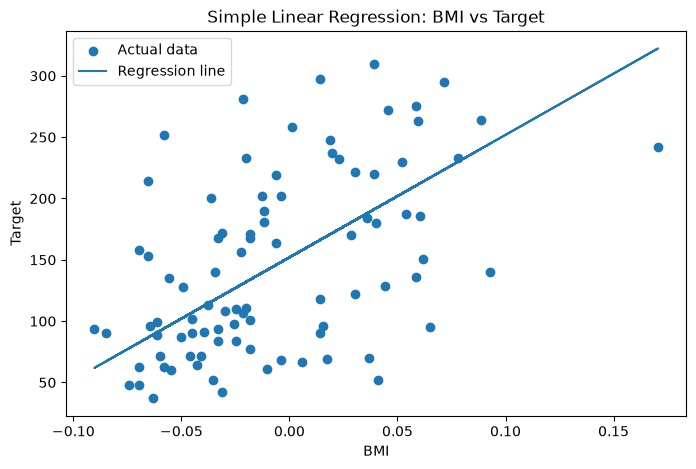

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["bmi"],
    y_test,
    label="Actual data"
)

plt.plot(
    X_test["bmi"],
    y_pred_simple,
    label="Regression line"
)

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Simple Linear Regression: BMI vs Target")
plt.legend()

plt.show()

In [17]:
X_multiple = df[["bmi", "bp", "s5"]]

y = df["target"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multiple,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[650.63,283.9 ,491.98]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['bmi','bp','s5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [20]:
print("Intercept:", multiple_model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(
    X_multiple.columns,
    multiple_model.coef_
):
    print(feature, ":", coefficient)

Intercept: 151.67416300012866

Coefficients:
bmi : 650.6313834139718
bp : 283.8989003965994
s5 : 491.9827115876337


In [21]:
y_pred_multiple = multiple_model.predict(X_test)

In [22]:
r2_multiple = r2_score(y_test, y_pred_multiple)

print("R² Score:", r2_multiple)

R² Score: 0.45433099153843404


In [23]:
mse_multiple = mean_squared_error(
    y_test,
    y_pred_multiple
)

print("MSE:", mse_multiple)

MSE: 2891.037211291966


In [24]:
rmse_multiple = np.sqrt(mse_multiple)

print("RMSE:", rmse_multiple)

RMSE: 53.768366269508


In [25]:
r2_simple = r2_score(y_test, y_pred_simple)

mse_simple = mean_squared_error(
    y_test,
    y_pred_simple
)

rmse_simple = np.sqrt(mse_simple)

print("Simple Regression")
print("------------------")
print("R²:", r2_simple)
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)

Simple Regression
------------------
R²: 0.23335039815872138
MSE: 4061.8259284949268
RMSE: 63.73245584860925


In [26]:
# Simple regression split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    df[["bmi"]],
    y,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_simple = simple_model.predict(X_test_s)


# Multiple regression split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    df[["bmi", "bp", "s5"]],
    y,
    test_size=0.2,
    random_state=42
)

multiple_model = LinearRegression()
multiple_model.fit(X_train_m, y_train_m)

y_pred_multiple = multiple_model.predict(X_test_m)


# Metrics
r2_simple = r2_score(y_test_s, y_pred_simple)
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

r2_multiple = r2_score(y_test_m, y_pred_multiple)
mse_multiple = mean_squared_error(y_test_m, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)


print("SIMPLE LINEAR REGRESSION")
print("-------------------------")
print("R²   :", r2_simple)
print("MSE  :", mse_simple)
print("RMSE :", rmse_simple)

print("\nMULTIPLE LINEAR REGRESSION")
print("---------------------------")
print("R²   :", r2_multiple)
print("MSE  :", mse_multiple)
print("RMSE :", rmse_multiple)

SIMPLE LINEAR REGRESSION
-------------------------
R²   : 0.23335039815872138
MSE  : 4061.8259284949268
RMSE : 63.73245584860925

MULTIPLE LINEAR REGRESSION
---------------------------
R²   : 0.45433099153843404
MSE  : 2891.037211291966
RMSE : 53.768366269508


In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "R²": [
        r2_simple,
        r2_multiple
    ],
    "MSE": [
        mse_simple,
        mse_multiple
    ],
    "RMSE": [
        rmse_simple,
        rmse_multiple
    ]
})

comparison

,Model,R²,MSE,RMSE
0,Simple Linear Regression,0.233350,4061.825928,63.732456
1,Multiple Linear Regression,0.454331,2891.037211,53.768366
